# TELCO CUSTOMER CHURN

## IMPORT, CONFIGURATION, LOAD DATA

In [22]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# Load data
data_path = Path('../data/raw/telco_customer_churn.csv')
df = pd.read_csv(data_path)

## INITIAL EXPLORATION

### Basic Info

In [23]:
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Dataset Shape: (7043, 21)
Rows: 7043, Columns: 21


In [24]:
print("FIRST FEW ROWS")
print("=" * 60)
df.head()

FIRST FEW ROWS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
print("DATA TYPES & MISSING VALUES")
print("=" * 60)
print(df.info())

DATA TYPES & MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

In [26]:
print("STATISTICAL SUMMARY")
print("=" * 60)
print(df.describe())

STATISTICAL SUMMARY
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [27]:
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values")
else:
    print(missing[missing > 0])

MISSING VALUES
No missing values


### Analyze Churn Distribution

In [28]:
print("CHURN DISTRIBUTION (TARGET VARIABLE)")
print("=" * 60)

# Count
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f"\nChurn Counts:")
print(churn_counts)

print(f"\nChurn Percentage:")
for category, pct in churn_pct.items():
    print(f"  {category}: {pct:.1f}%")

CHURN DISTRIBUTION (TARGET VARIABLE)

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
  No: 73.5%
  Yes: 26.5%


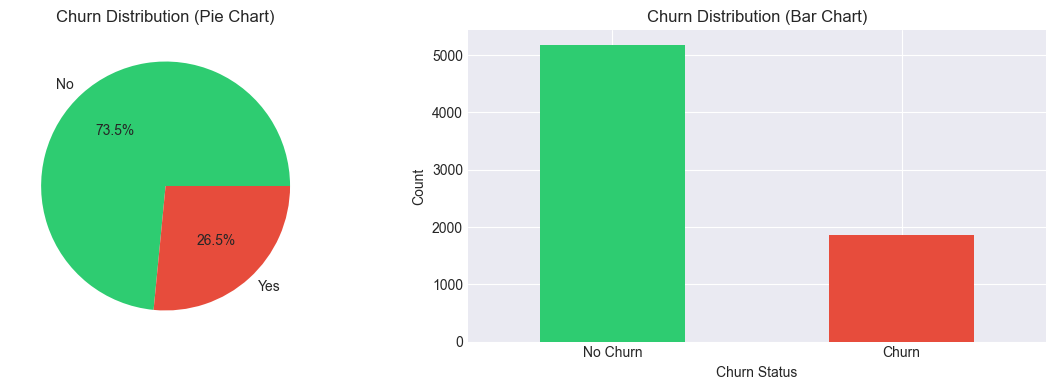

In [29]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
churn_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Pie Chart)')
axes[0].set_ylabel('')

# Bar chart
churn_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Distribution (Bar Chart)')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No Churn', 'Churn'], rotation=0)

plt.tight_layout()
plt.show()

Class imbalance observed:

26% positive class (churn) → Will need to handle in preprocessing phase

### Explore Feature Types

In [32]:
print("FEATURE TYPES & EXPLORATION")
print("=" * 60)

# Separate by type
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from categorical if present
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

print(f"\nNumeric Columns ({len(numeric_cols)}):")
print(numeric_cols)

print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols)

FEATURE TYPES & EXPLORATION

Numeric Columns (3):
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Columns (16):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


In [34]:
# Quick stats
print("KEY NUMERIC FEATURES")
print("=" * 60)
print(df[numeric_cols].describe().round(2))

KEY NUMERIC FEATURES
       SeniorCitizen   tenure  MonthlyCharges
count        7043.00  7043.00         7043.00
mean            0.16    32.37           64.76
std             0.37    24.56           30.09
min             0.00     0.00           18.25
25%             0.00     9.00           35.50
50%             0.00    29.00           70.35
75%             0.00    55.00           89.85
max             1.00    72.00          118.75


In [41]:
# Unique values in categorical
print("UNIQUE VALUES IN CATEGORICAL FEATURES")
print("=" * 60)
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Values: {df[col].unique()}")

UNIQUE VALUES IN CATEGORICAL FEATURES

gender:
  Unique values: 2
  Values: ['Female' 'Male']

Partner:
  Unique values: 2
  Values: ['Yes' 'No']

Dependents:
  Unique values: 2
  Values: ['No' 'Yes']

PhoneService:
  Unique values: 2
  Values: ['No' 'Yes']

MultipleLines:
  Unique values: 3
  Values: ['No phone service' 'No' 'Yes']

InternetService:
  Unique values: 3
  Values: ['DSL' 'Fiber optic' 'No']

OnlineSecurity:
  Unique values: 3
  Values: ['No' 'Yes' 'No internet service']

OnlineBackup:
  Unique values: 3
  Values: ['Yes' 'No' 'No internet service']

DeviceProtection:
  Unique values: 3
  Values: ['No' 'Yes' 'No internet service']

TechSupport:
  Unique values: 3
  Values: ['No' 'Yes' 'No internet service']

StreamingTV:
  Unique values: 3
  Values: ['No' 'Yes' 'No internet service']

StreamingMovies:
  Unique values: 3
  Values: ['No' 'Yes' 'No internet service']

Contract:
  Unique values: 3
  Values: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
  Unique v

### Correlation with Churn

In [52]:
print("CORRELATION WITH CHURN (NUMERIC FEATURES ONLY)")
print("=" * 60)

# Convert Churn to binary
churn_binary = (df['Churn'] == 'Yes').astype(int)

# Calculate correlation
numeric_df = df[numeric_cols].copy()
numeric_df['Churn_binary'] = churn_binary

correlations = numeric_df.corr()['Churn_binary'].sort_values(ascending=False)

print("\n")
print(correlations)

CORRELATION WITH CHURN (NUMERIC FEATURES ONLY)


Churn_binary      1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: Churn_binary, dtype: float64


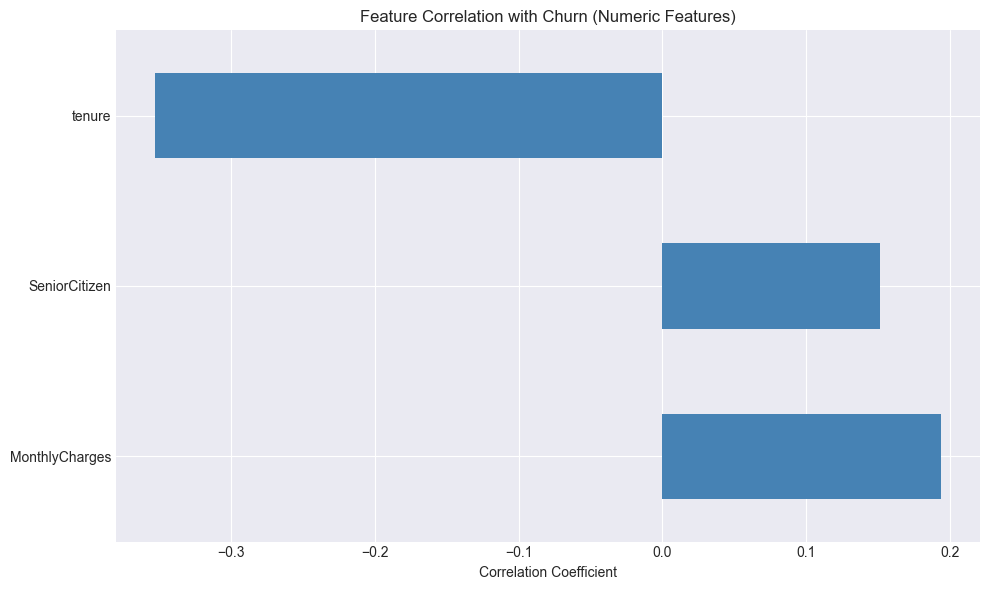

In [53]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

correlations_plot = correlations.drop('Churn_binary')

correlations_plot.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Correlation with Churn (Numeric Features)')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [55]:
print("\n✅ Key insights:")
print("   - Tenure shows NEGATIVE correlation (longer tenure = less likely to churn)")
print("   - MonthlyCharges shows POSITIVE correlation (higher charges = more likely to churn)")
print(f"   - Strongest predictor: Tenure (correlation: {correlations['tenure']:.3f})")


✅ Key insights:
   - Tenure shows NEGATIVE correlation (longer tenure = less likely to churn)
   - MonthlyCharges shows POSITIVE correlation (higher charges = more likely to churn)
   - Strongest predictor: Tenure (correlation: -0.352)


Key insights:

- Tenure shows NEGATIVE correlation (longer tenure = less likely to churn)
- MonthlyCharges shows POSITIVE correlation (higher charges = more likely to churn
- Strongest predictor: Tenure (correlation: -0.352)


## Save Checkpoint

In [60]:
# Save processed data snapshot for later use
df.to_csv('../data/raw/telco_customer_churn_loaded.csv', index=False)
print("Data checkpoint saved")

# Summary stats
print("\n" + "=" * 60)
print("SUMMARY: ")
print(f"Total samples: {len(df)}")
print(f"Total features: {len(df.columns)}")
print(f"Churn rate: {churn_pct['Yes']:.1f}%")
print(f"No churn rate: {churn_pct['No']:.1f}%")

Data checkpoint saved

SUMMARY: 
Total samples: 7043
Total features: 21
Churn rate: 26.5%
No churn rate: 73.5%


## Deep Dive EDA

### Correlation Heatmap

CORRELATION HEATMAP - ALL NUMERIC FEATURES


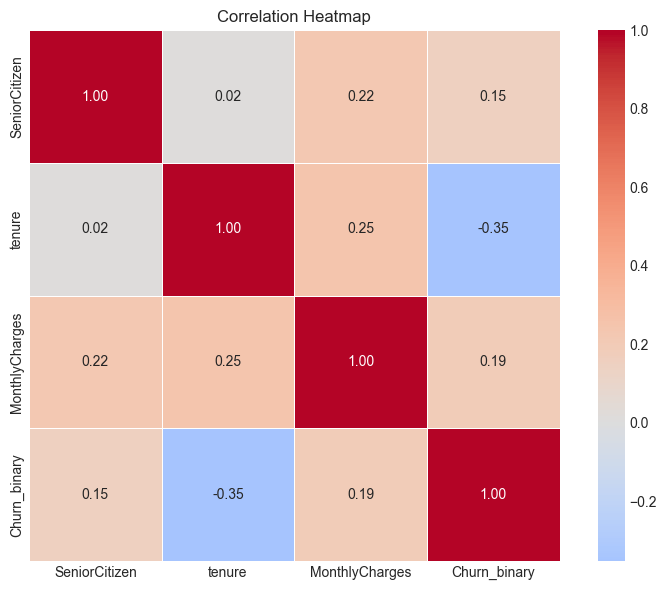

In [61]:
print("CORRELATION HEATMAP - ALL NUMERIC FEATURES")
print("=" * 60)

# Correlation matrix
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Tenure Analysis

TENURE ANALYSIS


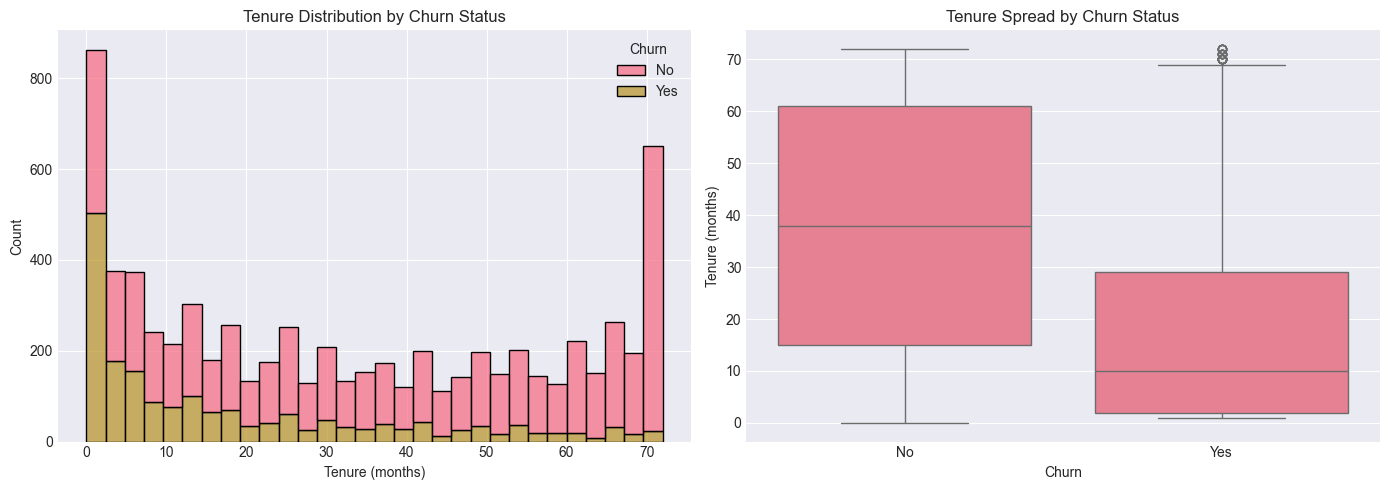

In [63]:
print("TENURE ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_xlabel('Tenure (months)')

# Box plot
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1])
axes[1].set_title('Tenure Spread by Churn Status')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.show()

In [65]:
# Summary stats
print("\nTenure Statistics by Churn Status:")
print(df.groupby('Churn')['tenure'].describe())

# Bucket analysis
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 48, 72],
                               labels=['0-6mo', '6-12mo', '12-24mo', '24-48mo', '48-72mo'])
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
print("\nChurn Rate by Tenure Bucket:")
print(tenure_churn)


Tenure Statistics by Churn Status:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0

Churn Rate by Tenure Bucket:
tenure_bucket
0-6mo      53.333333
6-12mo     35.886525
12-24mo    28.710938
24-48mo    20.388959
48-72mo     9.513176
Name: Churn, dtype: float64


### Monthly Charges Analysis

MONTHLY CHARGES ANALYSIS


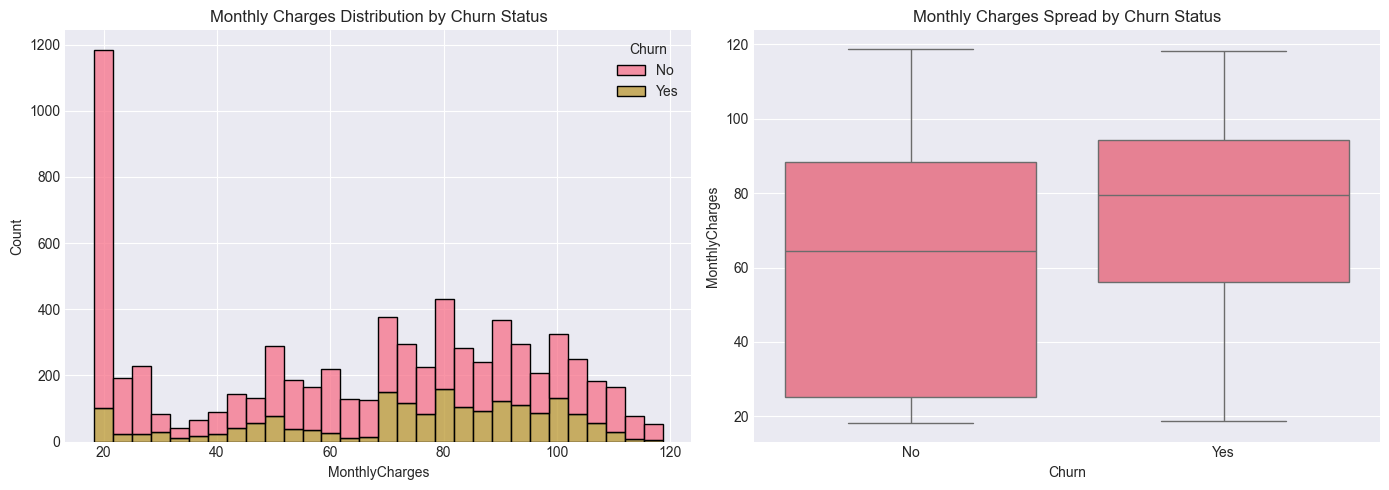

In [66]:
print("MONTHLY CHARGES ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30, ax=axes[0])
axes[0].set_title('Monthly Charges Distribution by Churn Status')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges Spread by Churn Status')

plt.tight_layout()
plt.show()

In [67]:
print("\nMonthly Charges Statistics by Churn Status:")
print(df.groupby('Churn')['MonthlyCharges'].describe())


Monthly Charges Statistics by Churn Status:
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


### Contract Type Analysis

CONTRACT TYPE ANALYSIS


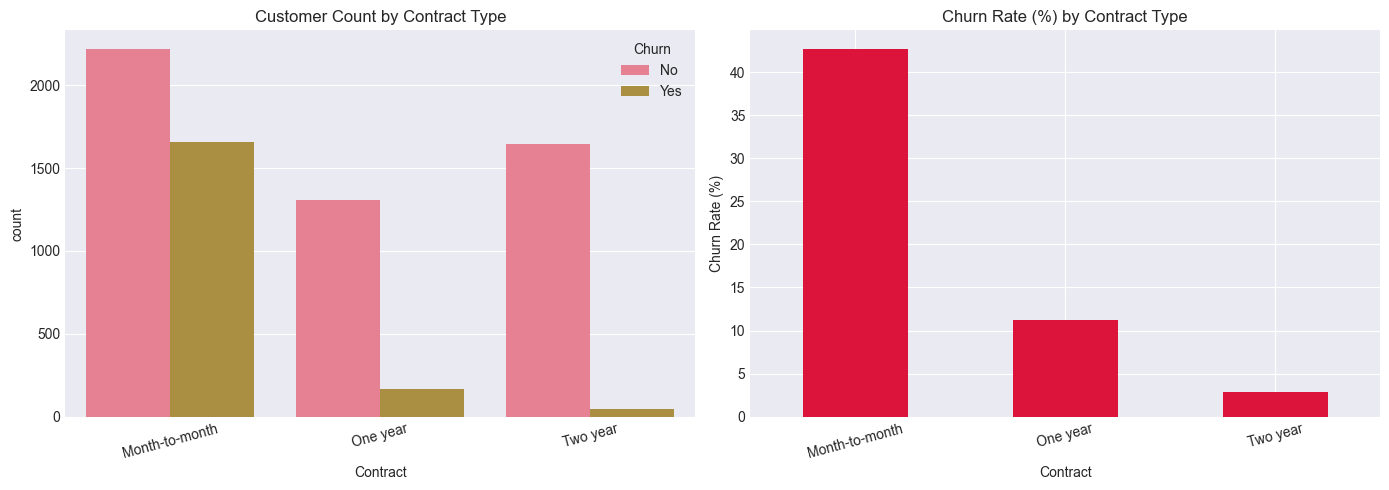

In [68]:
print("CONTRACT TYPE ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count by contract type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Customer Count by Contract Type')
axes[0].tick_params(axis='x', rotation=15)

# Churn rate by contract
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

contract_churn.plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Churn Rate (%) by Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [69]:
print("\nChurn Rate by Contract Type:")
print(contract_churn)


Churn Rate by Contract Type:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


### Other Categorical Features

CHURN RATE BY ALL CATEGORICAL FEATURES


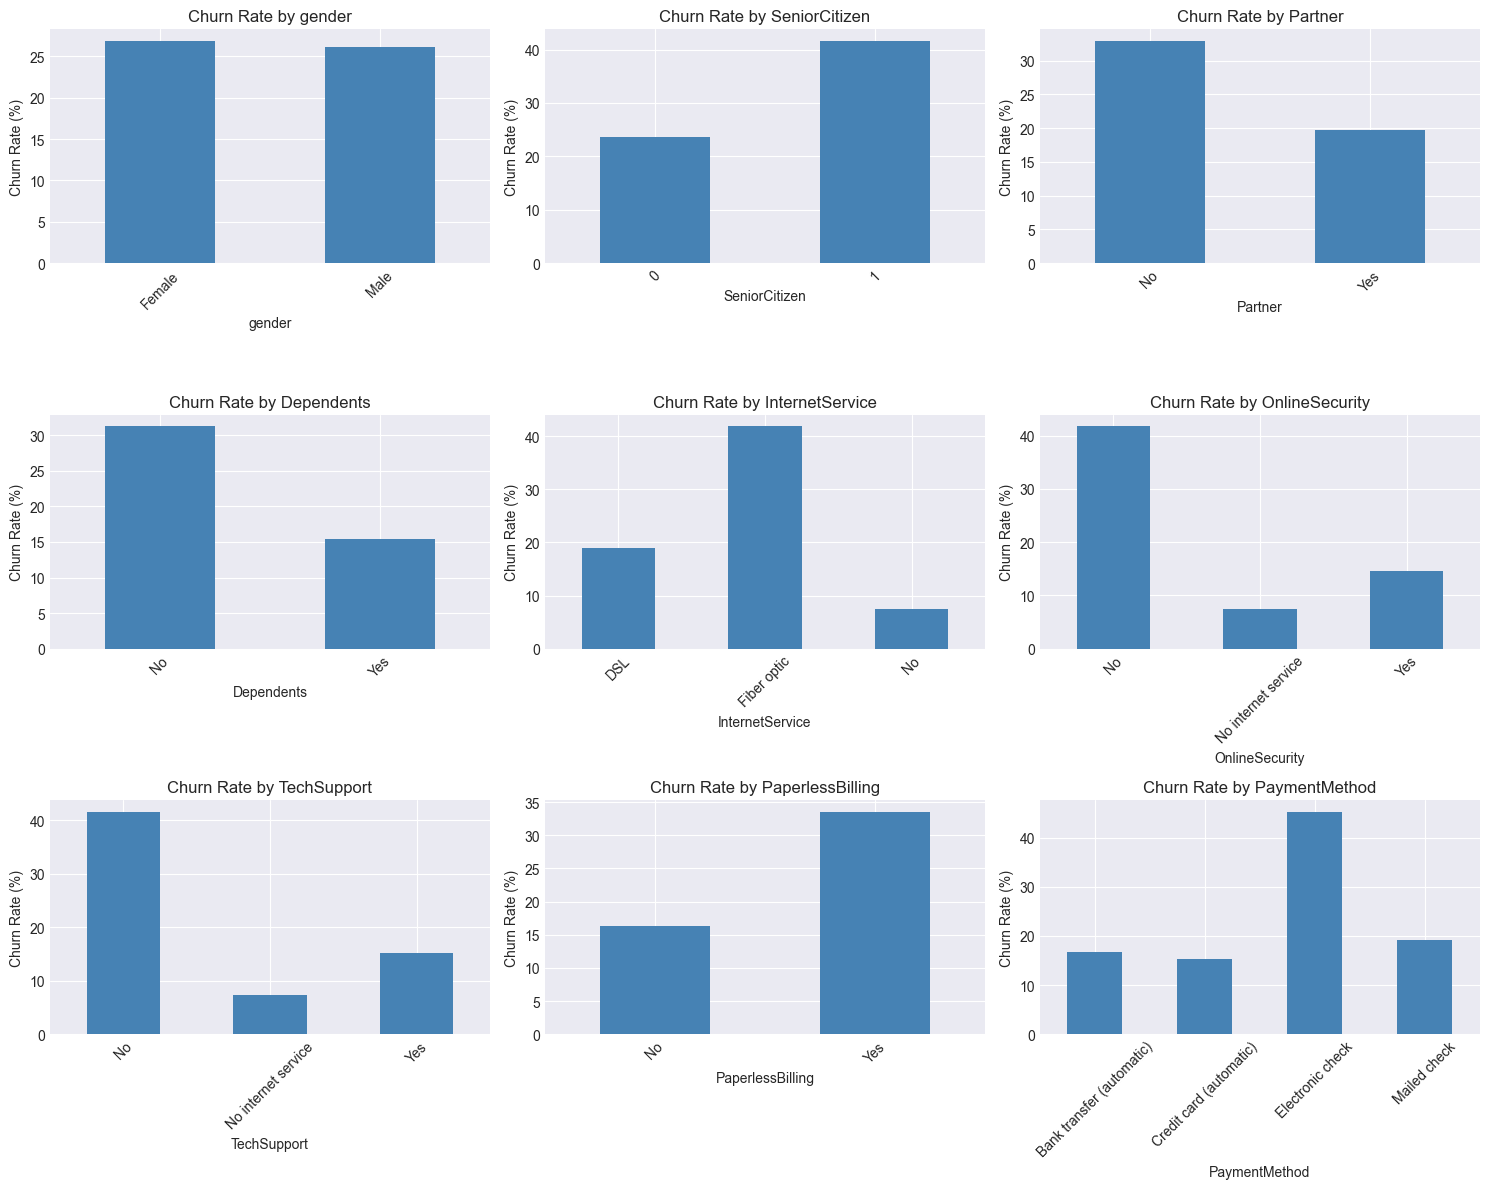

In [ ]:
print("CHURN RATE BY ALL CATEGORICAL FEATURES")
print("=" * 60)

# Choose the most relevant features that not have too many unique values
key_categorical = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'InternetService', 'OnlineSecurity', 'TechSupport',
                    'PaperlessBilling', 'PaymentMethod']

key_categorical = [col for col in key_categorical if col in df.columns]

n_cols = 3
n_rows = -(-len(key_categorical) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(key_categorical):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [77]:
print("\nDetailed Churn Rate by Feature:")
print("=" * 60)
for col in key_categorical:
    print(df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1))


Detailed Churn Rate by Feature:
gender
Female    26.9
Male      26.2
Name: Churn, dtype: float64
SeniorCitizen
0    23.6
1    41.7
Name: Churn, dtype: float64
Partner
No     33.0
Yes    19.7
Name: Churn, dtype: float64
Dependents
No     31.3
Yes    15.5
Name: Churn, dtype: float64
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64
OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6
Name: Churn, dtype: float64
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Churn, dtype: float64
PaperlessBilling
No     16.3
Yes    33.6
Name: Churn, dtype: float64
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn, dtype: float64


### Key Insights

1. **Tenure** — Strongest negative predictor
* Customers with a tenure of < 6 months have a significantly higher churn rate.
* Customers who stay for > 24 months tend to be highly loyal.


2. **Contract Type** — Highly influential
* Month-to-month contracts have a much higher churn rate compared to one-year or two-year contracts.
* This is a highly actionable business insight: incentivize customers to switch to long-term contracts.


3. **Monthly Charges** — Positive correlation with churn
* Customers with higher monthly charges are slightly more likely to churn.
* This is likely tied to their perception of value.


4. **Internet Service & Add-ons** (Online Security, Tech Support)
* Customers without add-on services (no internet service, no tech support) tend to have a higher churn rate.
* Insight: Service bundling can act as an effective retention strategy.


5. **Data Quality**
* Needs checking: Verify if any numeric columns were loaded as strings (for example, the `TotalCharges` column often has this issue in the Telco dataset).

### Check TotalCharges Data Type

In [79]:
print("TotalCharges DATA TYPE ISSUE")
print("=" * 60)

print(f"\nCurrent dtype: {df['TotalCharges'].dtype}")

# Check if there was any non-numeric values
non_numeric = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]
print(f"\nRows with non-numeric TotalCharges: {len(non_numeric)}")
if len(non_numeric) > 0:
    print(non_numeric[['customerID', 'tenure', 'TotalCharges']])
    print("\nIt usuallly a new customer (tenure=0) with empty TotalCharges")

TotalCharges DATA TYPE ISSUE

Current dtype: object

Rows with non-numeric TotalCharges: 11
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             

It usuallly a new customer (tenure=0) with empty TotalCharges
